In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
data_dir = Path('/projectnb2/npcr25/projects/two_photon/Ex1_jRGECO1a_ResonantScanning/processed')
run_dir = data_dir / 'TSeries-03042024-run02-054'

# Load data
F = np.load(run_dir / 'F.npy')
Fneu = np.load(run_dir / 'Fneu.npy')
iscell = np.load(run_dir / 'iscell.npy')

# Filter good cells
good_cells = iscell[:, 0] == 1
F_good = F[good_cells, :]
Fneu_good = Fneu[good_cells, :]

# 1. Apply neuropil correction
alpha = 0.7
F_corrected = F_good - alpha * Fneu_good

# 2. Calculate correlations per cell
corr_before = [np.corrcoef(F_good[i], Fneu_good[i])[0, 1] for i in range(F_good.shape[0])]
corr_after = [np.corrcoef(F_corrected[i], Fneu_good[i])[0, 1] for i in range(F_corrected.shape[0])]

print(f"Mean correlation before: {np.mean(corr_before):.3f}")
print(f"Mean correlation after: {np.mean(corr_after):.3f}")

Mean correlation before: 0.442
Mean correlation after: -0.128


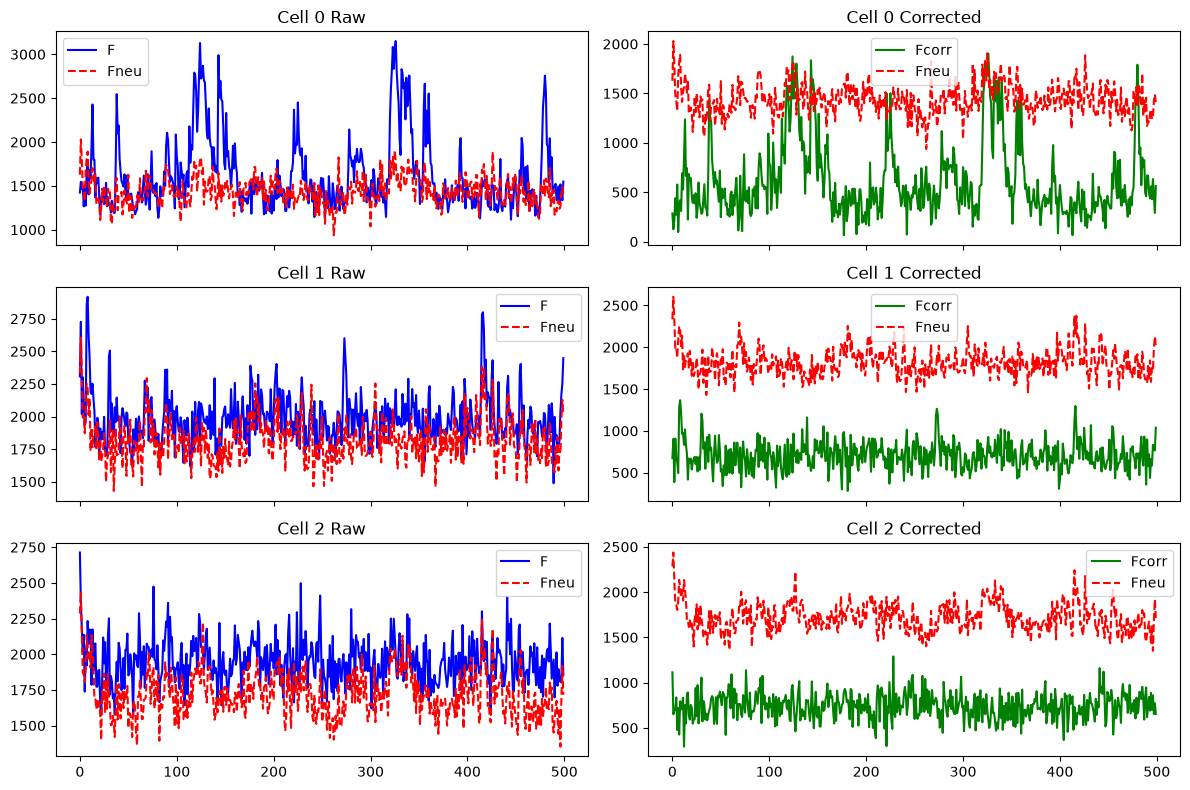

In [2]:
# 3. Plot example traces
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for i in range(3):
    axes[i, 0].plot(F_good[i, :500], label='F', color='blue')
    axes[i, 0].plot(Fneu_good[i, :500], label='Fneu', color='red', linestyle='--')
    axes[i, 0].set_title(f'Cell {i} Raw')
    axes[i, 1].plot(F_corrected[i, :500], label='Fcorr', color='green')
    axes[i, 1].plot(Fneu_good[i, :500], label='Fneu', color='red', linestyle='--')
    axes[i, 1].set_title(f'Cell {i} Corrected')
    axes[i, 0].legend(); axes[i, 1].legend()
plt.tight_layout()
plt.show()

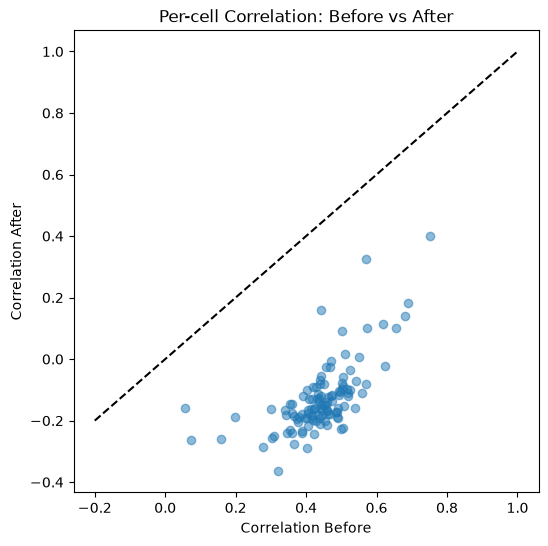

In [3]:
# 4. Plot correlations
plt.figure(figsize=(6, 6))
plt.scatter(corr_before, corr_after, alpha=0.5)
plt.plot([-0.2, 1], [-0.2, 1], 'k--')
plt.xlabel('Correlation Before')
plt.ylabel('Correlation After')
plt.title('Per-cell Correlation: Before vs After')
plt.show()